# Crude Oil Data Analysis for FOMC Decision Prediction

**Goal:**
This notebook performs a descriptive statistical analysis on historical WTI Crude Oil Prices alongside the Federal Funds target rate decisions. The aim is to explore whether crude oil price movements can serve as An alternative source of data to help predict future FOMC decisions.

We'll merge our processed Federal Funds data with the Crude Oil data, normalize the variables where appropriate, and conduct a correlation analysis to uncover any interesting patterns.


### 1. Load the Processed Federal Funds Data
We use the `%run` magic command to run the `process_data.ipynb` notebook and load the `df_decisions` DataFrame directly.


In [1]:
# Run the existing process_data.ipynb which creates the df_decisions dataframe
%run process_data.ipynb

# Display the processed data to ensure it loaded correctly
df_decisions.head()


Total meetings matched to rates: 140


,meeting_date,target_rate,previous_rate,rate_change,decision
0,2009-01-28,0.25,NaN,NaN,NaN
1,2009-03-18,0.25,0.25,0.0,same
2,2009-04-29,0.25,0.25,0.0,same
3,2009-06-24,0.25,0.25,0.0,same
4,2009-08-12,0.25,0.25,0.0,same
5,2009-09-23,0.25,0.25,0.0,same
6,2009-11-04,0.25,0.25,0.0,same
7,2009-12-16,0.25,0.25,0.0,same
8,2010-01-27,0.25,0.25,0.0,same
9,2010-03-16,0.25,0.25,0.0,same


Overall Rate Changes at Meetings (Distribution):


decision
same      108
higher     20
lower      11
Name: count, dtype: int64


Sample of Meetings where rates CHANGED:


,meeting_date,target_rate,previous_rate,rate_change,decision
55,2015-12-16,0.50,0.25,0.25,higher
63,2016-12-14,0.75,0.50,0.25,higher
65,2017-03-15,1.00,0.75,0.25,higher
67,2017-06-14,1.25,1.00,0.25,higher
71,2017-12-13,1.50,1.25,0.25,higher
73,2018-03-21,1.75,1.50,0.25,higher
75,2018-06-13,2.00,1.75,0.25,higher
77,2018-09-26,2.25,2.00,0.25,higher
79,2018-12-19,2.50,2.25,0.25,higher
84,2019-07-31,2.25,2.50,-0.25,lower


,meeting_date,target_rate,previous_rate,rate_change,decision
0,2009-01-28,0.25,NaN,NaN,NaN
1,2009-03-18,0.25,0.25,0.0,same
2,2009-04-29,0.25,0.25,0.0,same
3,2009-06-24,0.25,0.25,0.0,same
4,2009-08-12,0.25,0.25,0.0,same


### 2. Load the Crude Oil Data
We will now load the historical WTI Crude Oil Prices from our `data` folder. We must ensure the dates align correctly so we can evaluate the crude oil price just before each FOMC meeting.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load WTI Crude Oil Data
oil_path = 'https://raw.githubusercontent.com/echochoho1010/forecasting_fed_rate/master/data/WTI%20Crude%20Oil%20Prices.csv'
df_oil = pd.read_csv(oil_path)

# Ensure the Date column is in datetime format and values are numeric
if 'DATE' in df_oil.columns:
    df_oil['observation_date'] = pd.to_datetime(df_oil['DATE'], errors='coerce')
    df_oil['oil_price'] = pd.to_numeric(df_oil.iloc[:, 1], errors='coerce')
else:
    # Handle potentially different column names
    col_date = df_oil.columns[0]
    col_price = df_oil.columns[1]
    df_oil['observation_date'] = pd.to_datetime(df_oil[col_date], errors='coerce')
    df_oil['oil_price'] = pd.to_numeric(df_oil[col_price], errors='coerce')

df_oil = df_oil.dropna(subset=['observation_date', 'oil_price']).sort_values('observation_date').reset_index(drop=True)

df_oil.head()

### 3. Merging the Data
To predict the FOMC decision on a specific meeting date, we need to know the crude oil price *before* the decision is made. Thus, we will calculate the average crude oil price over the 30 days prior to each meeting, as well as the 30-day percentage change in the crude oil price leading up to the meeting.


In [3]:
# Prepare a list to store the rolling oil statistics for each meeting
oil_stats = []

for date in df_decisions['meeting_date']:
    # Get oil prices from the 30 days leading up to the meeting
    start_date = date - pd.Timedelta(days=30)
    history_30d = df_oil[(df_oil['observation_date'] >= start_date) & (df_oil['observation_date'] < date)]
    
    if not history_30d.empty:
        avg_price = history_30d['oil_price'].mean()
        # Price change from the start of the 30-day window to the end
        if history_30d['oil_price'].iloc[0] != 0:
            price_change_pct = (history_30d['oil_price'].iloc[-1] - history_30d['oil_price'].iloc[0]) / history_30d['oil_price'].iloc[0]
        else:
            price_change_pct = np.nan
    else:
        avg_price = np.nan
        price_change_pct = np.nan
        
    oil_stats.append({
        'meeting_date': date,
        'oil_price_30d_avg': avg_price,
        'oil_price_30d_pct_change': price_change_pct
    })

# Convert to DataFrame
df_oil_stats = pd.DataFrame(oil_stats)

# Merge back with the FOMC decisions
df_merged = pd.merge(df_decisions, df_oil_stats, on='meeting_date', how='inner').dropna()

df_merged.head()


,meeting_date,target_rate,previous_rate,rate_change,decision,oil_price_30d_avg,oil_price_30d_pct_change
1,2009-03-18,0.25,0.25,0.0,same,42.597143,0.400744
2,2009-04-29,0.25,0.25,0.0,same,49.531905,0.010724
3,2009-06-24,0.25,0.25,0.0,same,68.623810,0.101312
4,2009-08-12,0.25,0.25,0.0,same,66.632273,0.163679
5,2009-09-23,0.25,0.25,0.0,same,70.729048,-0.029587


### 4. Descriptive Statistics
Let's see how the crude oil price behaves in relation to the FOMC decisions.


oil_price_30d_avg                                              \
                     count       mean        std        min        25%   
decision                                                                 
higher                20.0  74.051288  21.303846  39.303333  55.837262   
lower                 11.0  60.074366   8.836063  44.809000  55.048193   
same                 108.0  71.261987  21.064311  16.563810  52.392643   

                                           oil_price_30d_pct_change            \
                50%        75%         max                    count      mean   
decision                                                                        
higher    73.987143  88.008999  115.965238                     20.0 -0.023841   
lower     59.581500  66.796667   72.506190                     11.0 -0.049792   
same      71.827857  86.868810  108.116190                    108.0  0.010947   

                                                                      
               std       min       25%       50%       75%       max  
decision                                                              
higher    0.101578 -0.193142 -0.105456 -0.028751  0.030923  0.224070  
lower     0.118686 -0.390352 -0.049809 -0.030703  0.009064  0.053698  
same      0.133241 -0.620717 -0.051069  0.010157  0.072975  0.622814

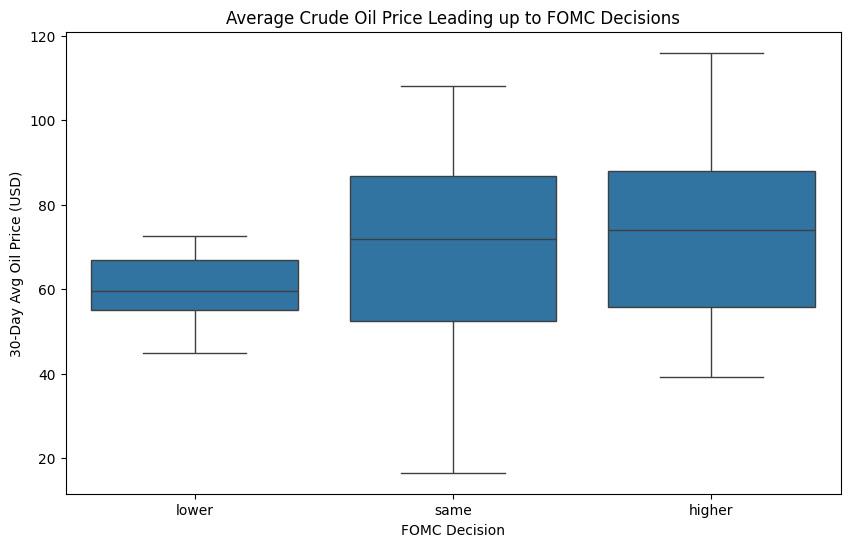

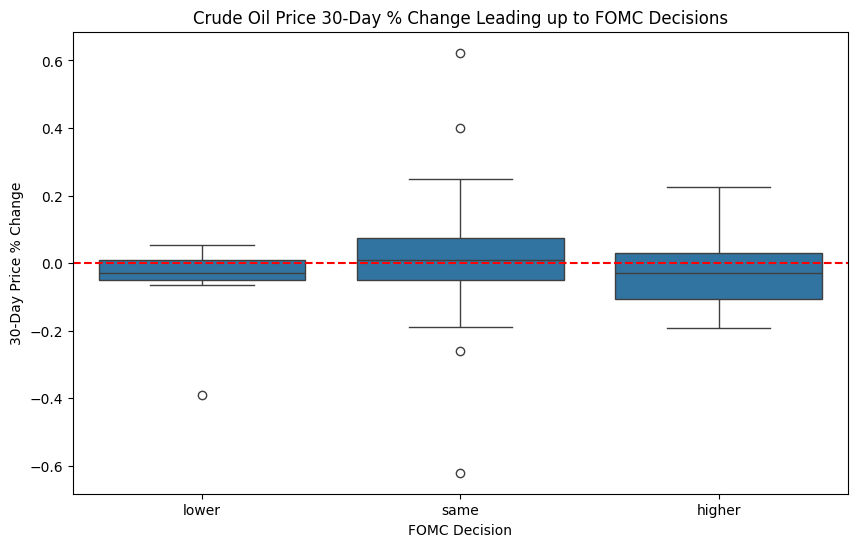

In [4]:
# Overview of descriptive statistics by decision type
display(df_merged.groupby('decision')[['oil_price_30d_avg', 'oil_price_30d_pct_change']].describe())

# Visualization of average oil prices before decisions
plt.figure(figsize=(10, 6))
sns.boxplot(x='decision', y='oil_price_30d_avg', data=df_merged, order=['lower', 'same', 'higher'])
plt.title('Average Crude Oil Price Leading up to FOMC Decisions')
plt.xlabel('FOMC Decision')
plt.ylabel('30-Day Avg Oil Price (USD)')
plt.show()

# Visualization of oil price percentage changes before decisions
plt.figure(figsize=(10, 6))
sns.boxplot(x='decision', y='oil_price_30d_pct_change', data=df_merged, order=['lower', 'same', 'higher'])
plt.title('Crude Oil Price 30-Day % Change Leading up to FOMC Decisions')
plt.xlabel('FOMC Decision')
plt.ylabel('30-Day Price % Change')
plt.axhline(0, color='red', linestyle='--')
plt.show()


**Interpretation:** 
From the boxplots above, we can see if rate hikes (`higher`) coincide with periods of high or rapidly increasing crude oil prices, which could indicate the Fed is reacting to commodity-driven inflation. Conversely, rate cuts (`lower`) might be associated with falling oil prices.


### 5. Normalized Features & Correlation Analysis
We will encode the categorical FOMC decision into numerical values (`lower = -1, same = 0, higher = 1`) and normalize the continuous variables to better understand their linear correlation.


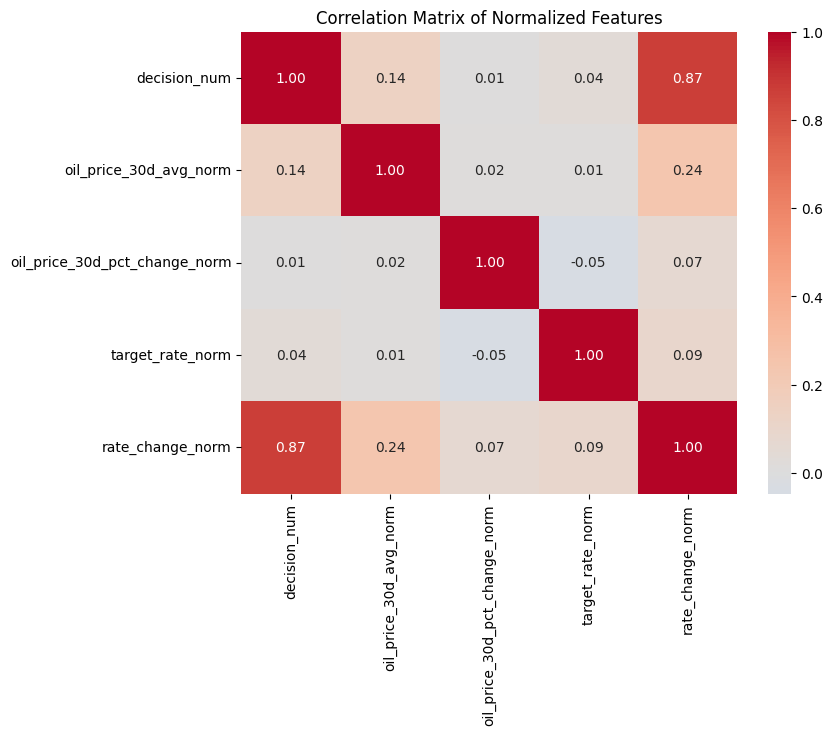

In [5]:
from sklearn.preprocessing import StandardScaler

# Map the decisions to numbers to compute correlation
num_decision_map = {'lower': -1, 'same': 0, 'higher': 1}
df_merged['decision_num'] = df_merged['decision'].map(num_decision_map)

# Select features to normalize
features = ['oil_price_30d_avg', 'oil_price_30d_pct_change', 'target_rate', 'rate_change']

# Standardize the continuous features (mean=0, std=1)
scaler = StandardScaler()
df_merged[[f + '_norm' for f in features]] = scaler.fit_transform(df_merged[features])

# Correlation Matrix
corr_matrix = df_merged[['decision_num'] + [f + '_norm' for f in features]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix of Normalized Features')
plt.show()


### 6. Conclusion
By examining the correlation matrix and the descriptive statistics, we can infer how strongly crude oil data dictates or signals the eventual Federal Funds rate decision. 

- **If the correlation between `oil_price_30d_pct_change_norm` and `decision_num` is high (> 0.3)**: This means increasing oil prices are a moderately good signal that rates will go up (often an anti-inflation measure).
- **If the correlation is low**: Crude oil on its own might not be a primary driver for the FOMC short-term rate decisions, but it can still be incorporated into a larger multivariate model like an LSTM or Random Forest.

This alternative dataset enriches our forecasting pipeline by capturing external commodity market pressures.
